Testing camera indices from 0 to 2...
--------------------------------------------------
✓ Camera 0: Found (640x480)
✓ Camera 1: Found (640x480)
--------------------------------------------------

Found 2 camera(s)


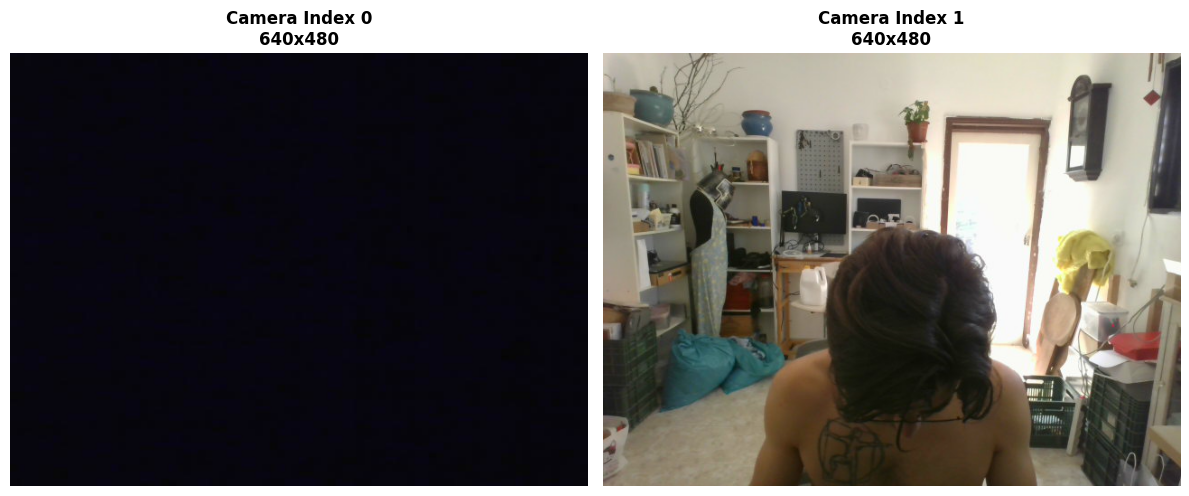

In [ ]:
import cv2
import matplotlib.pyplot as plt
from IPython.display import display, Image as IPImage
import numpy as np

def test_camera_indices(max_index=10):
    """
    Test camera indices from 0 to max_index and display captures from available cameras.
    
    Parameters:
    max_index (int): Maximum camera index to test (default: 10)
    """
    available_cameras = []
    
    print(f"Testing camera indices from 0 to {max_index}...")
    print("-" * 50)
    
    for index in range(max_index):
        # Try to open the camera
        cap = cv2.VideoCapture(index)
        
        if cap.isOpened():
            # Read a frame
            ret, frame = cap.read()
            
            if ret:
                # Store the camera info
                width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
                height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
                
                available_cameras.append({
                    'index': index,
                    'frame': frame,
                    'width': width,
                    'height': height
                })
                
                print(f"✓ Camera {index}: Found ({width}x{height})")
            else:
                print(f"✗ Camera {index}: Opened but couldn't read frame")
            
            cap.release()
        else:
            print(f"✗ Camera {index}: Not available")
            # If we've tried 3 indices in a row without success, likely no more cameras
            if index > 2 and all(cam['index'] < index - 2 for cam in available_cameras):
                print(f"\nNo cameras found after index {index-3}. Stopping search.")
                break
    
    print("-" * 50)
    print(f"\nFound {len(available_cameras)} camera(s)")
    
    # Display all captured frames
    if available_cameras:
        n_cameras = len(available_cameras)
        
        # Calculate grid layout
        cols = min(2, n_cameras)
        rows = (n_cameras + cols - 1) // cols
        
        # Create figure
        fig, axes = plt.subplots(rows, cols, figsize=(12, 6*rows))
        
        # Handle case with single camera
        if n_cameras == 1:
            axes = [axes]
        else:
            axes = axes.flatten() if n_cameras > 2 else axes
        
        # Display each camera's frame
        for i, cam_info in enumerate(available_cameras):
            # Convert BGR to RGB for matplotlib
            frame_rgb = cv2.cvtColor(cam_info['frame'], cv2.COLOR_BGR2RGB)
            
            axes[i].imshow(frame_rgb)
            axes[i].set_title(f"Camera Index {cam_info['index']}\n{cam_info['width']}x{cam_info['height']}", 
                            fontsize=12, fontweight='bold')
            axes[i].axis('off')
        
        # Hide any unused subplots
        for i in range(n_cameras, len(axes)):
            axes[i].axis('off')
        
        plt.tight_layout()
        plt.show()
    else:
        print("\n⚠ No cameras were found!")
        print("Make sure:")
        print("  - A camera is connected")
        print("  - Camera permissions are granted")
        print("  - No other application is using the camera")

# Run the camera test
test_camera_indices(max_index=1)